# Setup

In [1]:
!git clone https://github.com/IgnacioOQ/vaccine_ethics
%cd vaccine_ethics

Cloning into 'vaccine_ethics'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 249 (delta 39), reused 45 (delta 16), pack-reused 179 (from 1)
Receiving objects: 100% (249/249), 5.42 MiB | 23.80 MiB/s, done.
Resolving deltas: 100% (134/134), done.
/content/vaccine_ethics


In [2]:
from imports import *
from agent_class import FullAgent
from simulation_class import Simulation

In [3]:
!pip install scikit-optimize

from joblib import Parallel, delayed
from multiprocessing import cpu_count
from skopt import Optimizer
from skopt.space import Real
from skopt.plots import plot_convergence
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.express as px
import os
import time
import math


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.2 MB/s eta 0:00:00


In [4]:
print(f"Number of available CPU cores: {os.cpu_count()}")

Number of available CPU cores: 96


In [5]:
# Decide where to put the files and do the working
from google.colab import drive
drive.mount('/content/drive')

dump_path = '/content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/'
print("Current Directory:", dump_path)


Mounted at /content/drive
Current Directory: /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/


# Testing

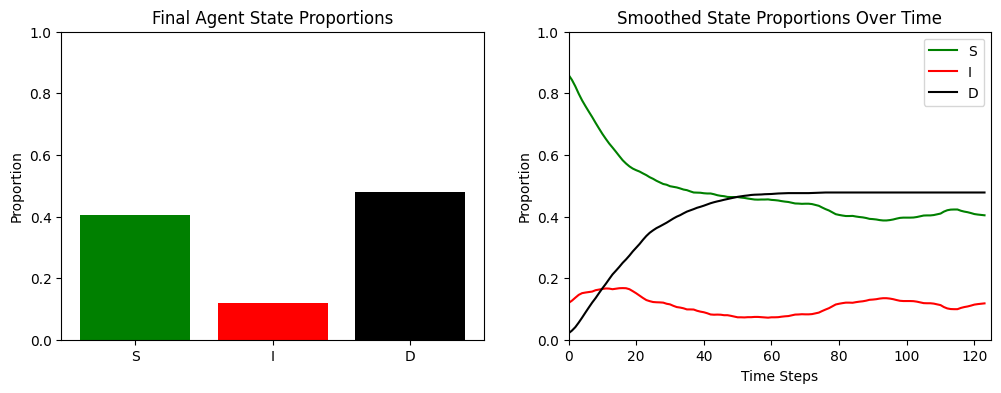

,step,dead_proportion,max_infected,auc_infected,avg_viral_age,avg_immunity,non_vulnerable_proportion_dead,vulnerable_proportion_dead,seed
0,123.0,0.478,0.178,13.819,5.968,0.526,0.461364,0.6,0.0


In [6]:
simulation_results = pd.DataFrame(columns=["step", "dead_proportion", "max_infected", "auc_infected", "avg_viral_age",
                                           "avg_immunity","non_vulnerable_proportion_dead","vulnerable_proportion_dead","seed",
                                           "total_unique_infected", "total_infections", "vul_infections", "non_vul_infections", "avg_reinfections"])


In [7]:
results[1]

np.float64(0.478)

# Bayesian Optimization with Parallelization (and n_trials)

## Plotting Functions

In [8]:

# # --- Plotting ---
def plot_3d_vax_hurts(df_results, filepath=None, title='Region Where Vaccination Increased Deaths'):
    df_results['actual_diff'] = -df_results['vax_harm_score']
    hurts_df = df_results[df_results['actual_diff'] > 0]

    if hurts_df.empty:
        print("No harmful vaccination outcomes found. Skipping 3D plot.")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = hurts_df['death_prob'], hurts_df['vax_effect'], hurts_df['viral_age_effect']
    harm = hurts_df['actual_diff']
    norm = mcolors.Normalize(vmin=harm.min(), vmax=harm.max())
    colors = cm.Reds(norm(harm))

    ax.scatter(x, y, z, c=colors, marker='o', alpha=0.9)
    ax.set_xlabel('Death Probability')
    ax.set_ylabel('Vaccine Effectiveness')
    ax.set_zlabel('Viral Age Effect')
    ax.set_title(title)

    mappable = cm.ScalarMappable(norm=norm, cmap=cm.Reds)
    mappable.set_array(harm)
    cbar = plt.colorbar(mappable, ax=ax, pad=0.1)
    cbar.set_label('Vaccination Harm (Δ deaths)')

    plt.tight_layout()
    filepath = filepath or dump_path + "vax_hurts_3d_plot.png"
    plt.savefig(filepath, dpi=300)
    print(f"Plot saved to {filepath}")
    plt.show()


# # --- Plotting ---
def plot_3d_delta_auc(df_results, filepath=None,title='Region Where Vaccination Increased Infection AUC'):
    auc_hurts_df = df_results[df_results['delta_auc'] > 0]

    if auc_hurts_df.empty:
        print("No harmful vaccination outcomes found. Skipping 3D plot.")
        return

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    x, y, z = auc_hurts_df['death_prob'], auc_hurts_df['vax_effect'], auc_hurts_df['viral_age_effect']
    harm = auc_hurts_df['delta_auc']
    norm = mcolors.Normalize(vmin=harm.min(), vmax=harm.max())
    colors = cm.Reds(norm(harm))

    ax.scatter(x, y, z, c=colors, marker='o', alpha=0.9)
    ax.set_xlabel('Death Probability')
    ax.set_ylabel('Vaccine Effectiveness')
    ax.set_zlabel('Viral Age Effect')
    ax.set_title(title)

    mappable = cm.ScalarMappable(norm=norm, cmap=cm.Reds)
    mappable.set_array(harm)
    cbar = plt.colorbar(mappable, ax=ax, pad=0.1)
    cbar.set_label('Vaccination Harm (Δ Infection AUC)')

    plt.tight_layout()
    filepath = filepath or dump_path + "vax_hurts_delta_auc_3d_plot.png"
    plt.savefig(filepath, dpi=300)
    print(f"Plot saved to {filepath}")
    plt.show()

def plotly_3d_vax_hurts(df_results, output_html=None):
    df_results['actual_diff'] = -df_results['vax_harm_score']
    hurts_df = df_results[df_results['actual_diff'] > 0]

    if hurts_df.empty:
        print("No harmful vaccination outcomes found. Skipping Plotly plot.")
        return

    fig = px.scatter_3d(
        hurts_df,
        x='death_prob',
        y='vax_effect',
        z='viral_age_effect',
        color='actual_diff',
        color_continuous_scale='Reds',
        title='Interactive 3D: Where Vaccination Increased Deaths',
        labels={'actual_diff': 'Vax Harm (Δ deaths)'},
        opacity=0.8
    )

    fig.update_traces(marker=dict(size=5))
    output_html = output_html or dump_path + "interactive_vax_hurts_plot.html"
    fig.write_html(output_html)
    print(f"Interactive 3D plot saved to '{output_html}'")
    fig.show()

def plot_dead_delta_comparison(df):
    """
    Generates a scatter plot comparing non-vulnerable and vulnerable
    death proportion deltas from a simulation CSV file.

    Parameters:
        csv_path (str): Path to the CSV file containing
                        'non_vul_proportion_dead_delta' and
                        'vulnerable_proportion_dead_delta' columns.
    """
    # Load data
    # df = pd.read_csv(csv_path)

    # Create scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(df['non_vul_proportion_dead_delta'],
                df['vulnerable_proportion_dead_delta'],
                alpha=0.6)

    # Zero reference lines
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)

    # Labels and title
    plt.xlabel('Non-vulnerable Dead Delta')
    plt.ylabel('Vulnerable Dead Delta')
    plt.title('Comparison of Death Deltas\n(Non-vulnerable vs Vulnerable)')

    # Equal delta reference line
    lims = [
        min(df['non_vul_proportion_dead_delta'].min(), df['vulnerable_proportion_dead_delta'].min()),
        max(df['non_vul_proportion_dead_delta'].max(), df['vulnerable_proportion_dead_delta'].max()),
    ]
    plt.plot(lims, lims, 'r--', alpha=0.7, label='Equal Deltas')

    plt.legend()
    plt.tight_layout()
    filepath = dump_path + "delta_prop_deaths_comparison.png"
    plt.savefig(filepath, dpi=300)
    print(f"Plot saved to {filepath}")
    plt.show()

## Parameters

In [ ]:
# --- Fixed Parameters ---
grid_size = 25
num_agents = 500
init_infected_proportion = 0.1
proportion_vulnerable = 0.1
recovery_time = 30

fixed_infection_prob = 0.25
fixed_immune_adaptation_effect = 0.05
fixed_vul_penalty = 2

# --- Search Space (reduced) ---
space = [
    Real(0.01, 0.9, name='death_prob'),
    Real(0.1, 0.9, name='vax_effect'),
    Real(0.1, 0.9, name='viral_age_effect')]

## Main Function

In [ ]:

# --- Averaged Simulation Runner ---
def average_simulation_metrics(params, n_trials, inner_workers=None):
    """Runs simulation n_trials times in parallel and returns averaged metrics."""
    if n_trials < 1:
        raise ValueError("n_trials must be at least 1.")

    inner_workers = inner_workers or min(cpu_count(), n_trials)

    trial_results = Parallel(n_jobs=inner_workers, backend="threading")(
        delayed(run_simulation_for_params)(params) for _ in range(n_trials)
    )

    avg_result = {}
    keys = trial_results[0].keys()

    for key in keys:
        values = [res[key] for res in trial_results]
        if isinstance(values[0], (float, int)):
            avg_result[key] = np.mean(values)
        else:
            avg_result[key] = values[0]  # Preserve params or other non-numeric values

    return avg_result



def run_simulation_for_params(params):
    """Evaluate harm caused (or prevented) by vaccinating all vs vulnerable-only."""
    results = {}
    ss = np.random.SeedSequence()
    seed_int = int(ss.generate_state(1, dtype=np.uint32)[0])
    rngseed=random.seed(seed_int)
    nprngseed=np.random.default_rng(seed_int)

    for vax_all in [True, False]:
        simulation = Simulation(
            grid_size=grid_size,
            num_agents=num_agents,
            agent_class=FullAgent,
            init_infected_proportion=init_infected_proportion,
            proportion_vulnerable=proportion_vulnerable,
            vul_penalty=fixed_vul_penalty,
            infection_prob=fixed_infection_prob,
            recovery_time=recovery_time,
            death_prob=params[0],
            vax_vulnerable=True,
            vax_all=vax_all,
            vax_effect=params[1],
            viral_age_effect=params[2],
            immune_adaptation_effect=fixed_immune_adaptation_effect,
            plot=False,
            rngseed=rngseed,
            nprngseed=nprngseed,
            seed=seed_int,
        )
        simulation.run()
        report = simulation.generate_simulation_report()
        results[vax_all] = {
            'steps': report[0],
            'deaths': report[1],
            'auc_infected': report[3],
            'avg_viral_age': report[4],
            'avg_immunity': report[5],
            'non_vul_proportion_dead': report[6],
            'vulnerable_proportion_dead': report[7],
            'seed': report[8],  # Store the seed for reproducibility
            'total_unique_infected': report[9],
            'total_infections': report[10],
            'vul_infections': report[11],
            'non_vul_infections': report[12],
            'avg_reinfections': report[13]
        }

    harm = results[True]['deaths'] - results[False]['deaths']
    auc_diff = results[True]['auc_infected'] - results[False]['auc_infected']

    return {
        'harm': -harm,
        'deaths_vax': results[True]['deaths'],
        'deaths_no_vax': results[False]['deaths'],
        'steps_vax': results[True]['steps'],
        'steps_no_vax': results[False]['steps'],
        'auc_vax': results[True]['auc_infected'],
        'auc_no_vax': results[False]['auc_infected'],
        'delta_auc': auc_diff,
        'non_vul_proportion_dead_delta': results[True]['non_vul_proportion_dead'] - results[False]['non_vul_proportion_dead'],
        'vulnerable_proportion_dead_delta': results[True]['vulnerable_proportion_dead'] - results[False]['vulnerable_proportion_dead'],
        'viral_age_delta': results[True]['avg_viral_age'] - results[False]['avg_viral_age'],
        'immunity_delta': results[True]['avg_immunity'] - results[False]['avg_immunity'],
        'total_unique_infected_delta': results[True]['total_unique_infected'] - results[False]['total_unique_infected'],
        'total_infections_delta': results[True]['total_infections'] - results[False]['total_infections'],
        'vul_infections_delta': results[True]['vul_infections'] - results[False]['vul_infections'],
        'non_vul_infections_delta': results[True]['non_vul_infections'] - results[False]['non_vul_infections'],
        'avg_reinfections_delta': results[True]['avg_reinfections'] - results[False]['avg_reinfections'],
        'params': params,
        'seeds': (results[True]['seed'],results[False]['seed'])
        # 'auc_delta': results[True]['auc_infected'] - results[False]['auc_infected'],
    }


# --- Parallel Evaluation ---
def parallel_objective(params_batch, progress_desc="Running Batch", num_workers=None, n_trials=5):
    """Parallelized wrapper for simulation trials per parameter set."""
    num_workers = num_workers or cpu_count()
    print(f"Using {num_workers} workers")


    results = Parallel(n_jobs=num_workers)(
    delayed(average_simulation_metrics)(params, n_trials) for params in tqdm(params_batch, desc=progress_desc)
)

    return results


# --- BO Runner ---
def run_bayesian_optimization(
    n_calls=300,
    n_initial_points=50,
    parallel_batch_size=50,
    num_workers=None,
    n_trials=5
):
    print(f"\n--- Running BO with n_trials={n_trials} for fixed immune_adaptation_effect={fixed_immune_adaptation_effect}, infection_prob={fixed_infection_prob}, vul_penalty={fixed_vul_penalty} ---")
    results_list = []

    def batch_objective(params_batch, desc):
        batch_results = parallel_objective(params_batch, desc, num_workers, n_trials=n_trials)
        for p, res in zip(params_batch, batch_results):
            results_list.append({
                'death_prob': p[0],
                'vul_penalty': fixed_vul_penalty,
                'vax_effect': p[1],
                'viral_age_effect': p[2],
                'immune_adaptation_effect': fixed_immune_adaptation_effect,
                'infection_prob': fixed_infection_prob,
                'vax_harm_score': res['harm'],
                'deaths_vax': res['deaths_vax'],
                'deaths_no_vax': res['deaths_no_vax'],
                'steps_vax': res['steps_vax'],
                'steps_no_vax': res['steps_no_vax'],
                'auc_vax': res['auc_vax'],
                'auc_no_vax': res['auc_no_vax'],
                'delta_auc': res['delta_auc'],
                'non_vul_proportion_dead_delta': res['non_vul_proportion_dead_delta'],
                'vulnerable_proportion_dead_delta': res['vulnerable_proportion_dead_delta'],
                'seeds': res['seeds'],
                'viral_age_delta': res['viral_age_delta'],
                'immunity_delta': res['immunity_delta'],
                'total_unique_infected_delta': res['total_unique_infected_delta'],
                'total_infections_delta': res['total_infections_delta'],
                'vul_infections_delta': res['vul_infections_delta'],
                'non_vul_infections_delta': res['non_vul_infections_delta'],
                'avg_reinfections_delta': res['avg_reinfections_delta'],
            })
        return [r['harm'] for r in batch_results]

    opt = Optimizer(
        dimensions=space,
        base_estimator="GP",
        acq_func="LCB",
        acq_func_kwargs={"kappa": 3.0},
        acq_optimizer="sampling",  # avoids repeat points
        random_state=42
    )


    # opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="gp_hedge", random_state=42)

    initial_params = opt.ask(n_initial_points)
    batch_objective(initial_params, desc="Initial Random Sampling")
    opt.tell(initial_params, [r['vax_harm_score'] for r in results_list])

    num_batches = (n_calls - n_initial_points) // parallel_batch_size
    for i in tqdm(range(num_batches), desc="Bayesian Optimization Progress"):
        next_params = opt.ask(parallel_batch_size)
        batch_results = batch_objective(next_params, desc=f"Batch {i+1}/{num_batches}")
        opt.tell(next_params, batch_results)

    df_results = pd.DataFrame(results_list)
    df_results.to_csv(dump_path + 'bo_results_fixed_params_seeding.csv', index=False)
    print("Bayesian Optimization complete! Results saved to 'bo_results_fixed_params_seeding.csv'.")

    vax_hurts_df = get_vax_hurts_region(df_results)
    plot_3d_vax_hurts(df_results)
    plotly_3d_vax_hurts(df_results)
    plot_3d_delta_auc(df_results)
    return df_results, vax_hurts_df


# --- Harm Region Analysis ---
def get_vax_hurts_region(df_results):
    df_results['actual_diff'] = -df_results['vax_harm_score']
    hurts = df_results[df_results['actual_diff'] > 0]
    print(f"\nFound {len(hurts)} parameter sets where vaccination increased deaths.")
    hurts.to_csv(dump_path + 'vax_hurts_region_seeding.csv', index=False)
    return hurts


## Run Optimization


--- Running BO with n_trials=200 for fixed immune_adaptation_effect=0.05, infection_prob=0.25, vul_penalty=2 ---
Using 96 workers


Bayesian Optimization Progress:   0%|          | 0/7 [00:00<?, ?it/s]

Using 96 workers



Bayesian Optimization Progress:  14%|█▍        | 1/7 [1:29:31<8:57:10, 5371.73s/it]

Using 96 workers


...

Using 96 workers



Bayesian Optimization Progress:  86%|████████▌ | 6/7 [10:07:43<1:54:25, 6865.88s/it]

Using 96 workers



Bayesian Optimization Progress: 100%|██████████| 7/7 [11:34:39<00:00, 5954.19s/it]


Bayesian Optimization complete! Results saved to 'bo_results_fixed_params_seeding.csv'.

Found 534 parameter sets where vaccination increased deaths.
Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/vax_hurts_3d_plot.png


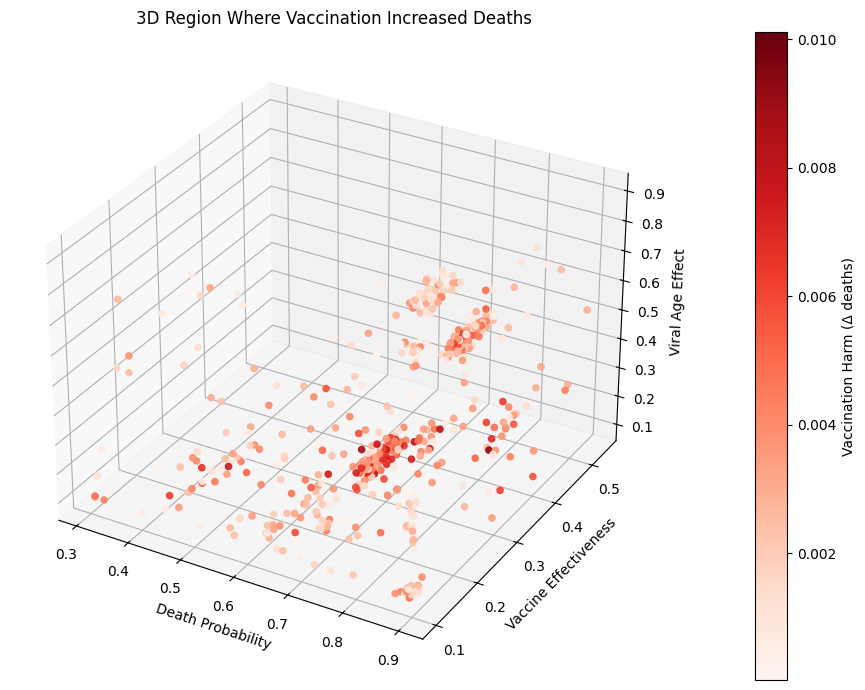

Interactive 3D plot saved to '/content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/interactive_vax_hurts_plot.html'


Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/vax_hurts_delta_auc_3d_plot.png


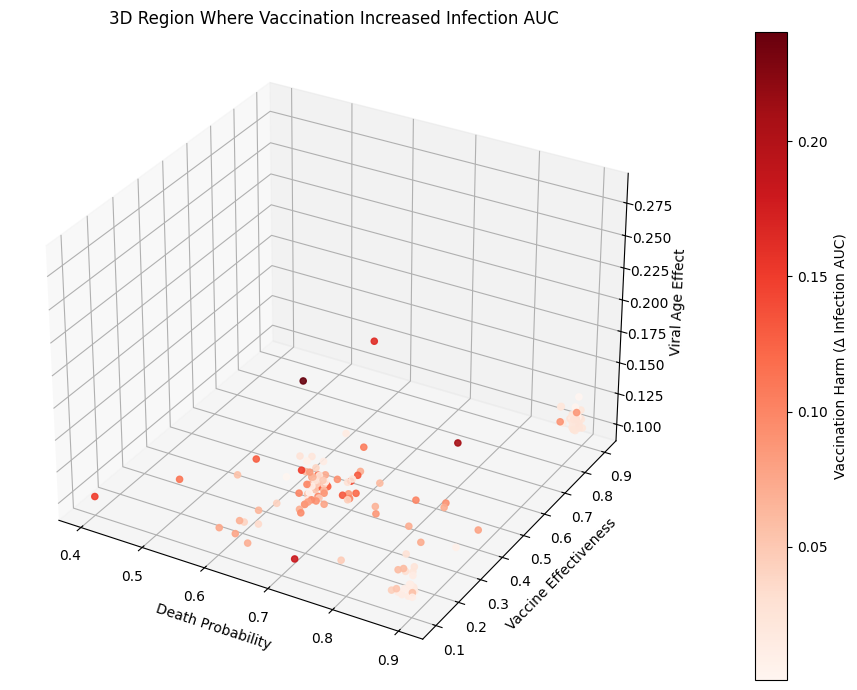

CPU times: user 4d 4h 43min 38s, sys: 11min 33s, total: 4d 4h 55min 11s
Wall time: 14h 29min 11s


In [ ]:
# --- Run Optimization ---
%%time
if __name__ == "__main__":
    df_results, vax_hurts_df = run_bayesian_optimization(
        n_calls=1000,
        n_initial_points=250,
        parallel_batch_size=100,
        num_workers=None,  # Use all cores
        n_trials=200
    )

In [ ]:
vax_hurts_df.head(10)

,death_prob,vul_penalty,vax_effect,viral_age_effect,immune_adaptation_effect,infection_prob,vax_harm_score,deaths_vax,deaths_no_vax,steps_vax,steps_no_vax,auc_vax,auc_no_vax,delta_auc,non_vul_proportion_dead_delta,vulnerable_proportion_dead_delta,seeds,viral_age_delta,immunity_delta,actual_diff
10,0.874969,2,0.103229,0.886317,0.05,0.25,-0.00163,0.11208,0.11045,64.470,64.705,14.581945,17.106800,-2.524855,0.000179,0.015345,"(651904202.0, 651904202.0)",-0.41708,-0.00040,0.00163
11,0.899077,2,0.112864,0.127725,0.05,0.25,-0.00224,0.11891,0.11667,4.275,4.230,0.045040,0.111810,-0.066770,0.001609,0.007682,"(4053416433.0, 4053416433.0)",-0.08791,-0.00162,0.00224
13,0.895863,2,0.104044,0.111092,0.05,0.25,-0.00153,0.11825,0.11672,3.730,3.195,0.034410,0.022280,0.012130,0.000878,0.006809,"(397392894.0, 397392894.0)",-0.00024,0.00000,0.00153
27,0.887273,2,0.114179,0.899711,0.05,0.25,-0.00261,0.11190,0.10929,63.390,64.350,14.205525,17.480040,-3.274515,0.002607,0.002591,"(3639924488.0, 3639924488.0)",-0.64702,-0.03611,0.00261
30,0.882273,2,0.107799,0.100287,0.05,0.25,-0.00134,0.11862,0.11728,4.045,3.135,0.036550,0.023505,0.013045,0.000379,0.009933,"(149708087.0, 149708087.0)",0.00269,0.00000,0.00134
35,0.858777,2,0.122313,0.882438,0.05,0.25,-0.00016,0.11154,0.11138,64.825,65.350,14.070790,17.142130,-3.071340,-0.000369,0.004040,"(1068026598.0, 1068026598.0)",-0.60213,-0.02099,0.00016
36,0.897139,2,0.120123,0.103371,0.05,0.25,-0.00145,0.11814,0.11669,3.835,2.805,0.035630,0.020795,0.014835,0.001578,-0.000839,"(2405218162.0, 2405218162.0)",0.00223,0.00000,0.00145
43,0.896674,2,0.111473,0.894431,0.05,0.25,-0.00078,0.11047,0.10969,63.490,64.290,13.652900,16.142995,-2.490095,0.000396,0.004128,"(3682372562.0, 3682372562.0)",-0.44969,-0.00678,0.00078
54,0.892580,2,0.135483,0.884827,0.05,0.25,-0.00066,0.11367,0.11301,64.535,63.615,13.275965,16.144720,-2.868755,-0.000662,0.012080,"(3762126364.0, 3762126364.0)",-0.39612,0.00787,0.00066
57,0.883310,2,0.123200,0.883614,0.05,0.25,-0.00159,0.11238,0.11079,64.140,64.575,13.722495,16.703900,-2.981405,0.000723,0.010023,"(4014822378.0, 4014822378.0)",-0.45377,-0.02929,0.00159


## Plotting

Viral age effect stats:
count    534.000000
mean       0.361971
std        0.245379
min        0.100009
25%        0.134241
50%        0.259687
75%        0.605637
max        0.899711
Name: viral_age_effect, dtype: float64
Min value in viral_age_effect: 0.1000086829078923
Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/vax_hurts_3d_plot.png


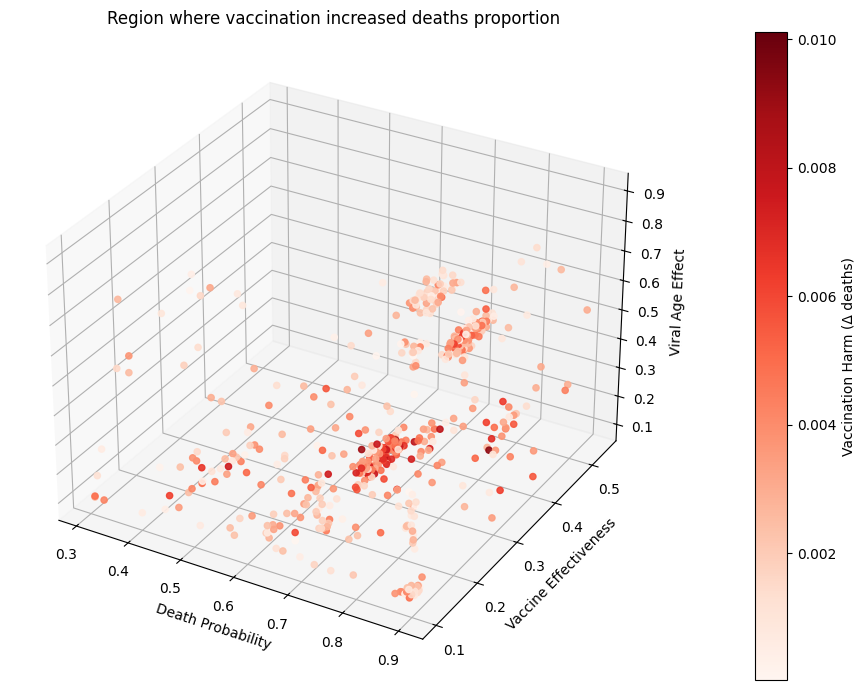

Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/vax_hurts_delta_auc_3d_plot.png


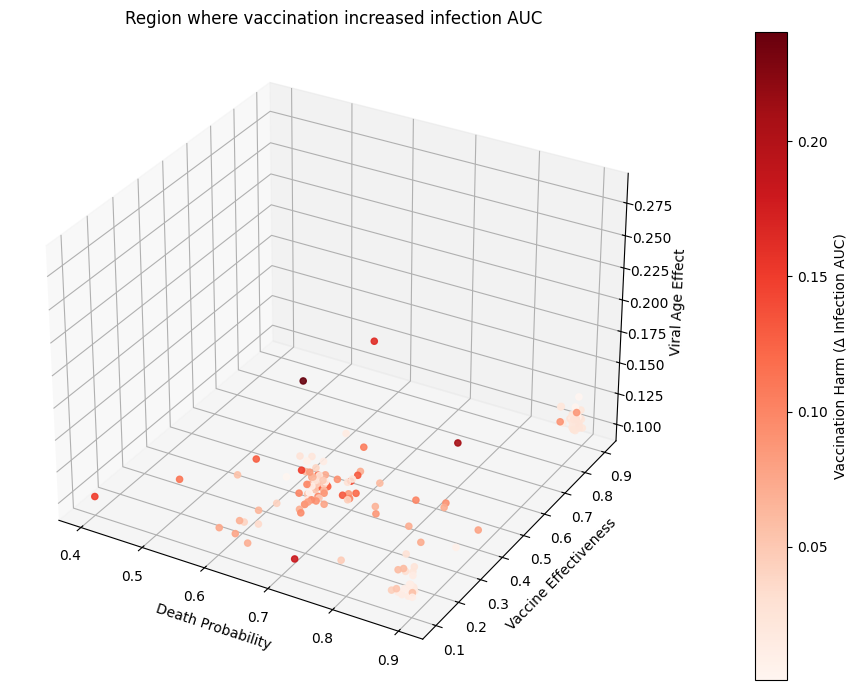

Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/vax_hurts_delta_auc_3d_plot.png


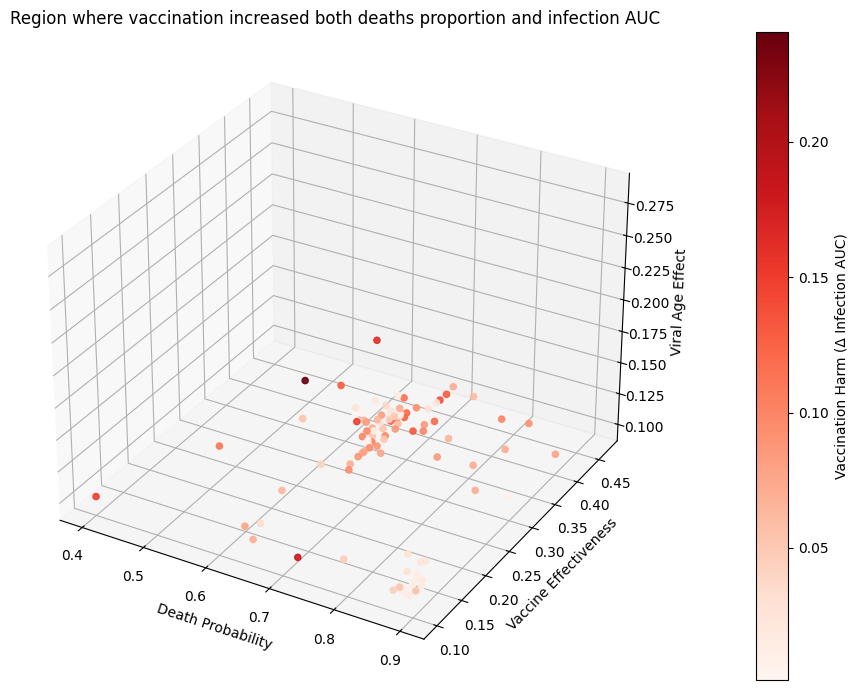

Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/delta_prop_deaths_comparison.png


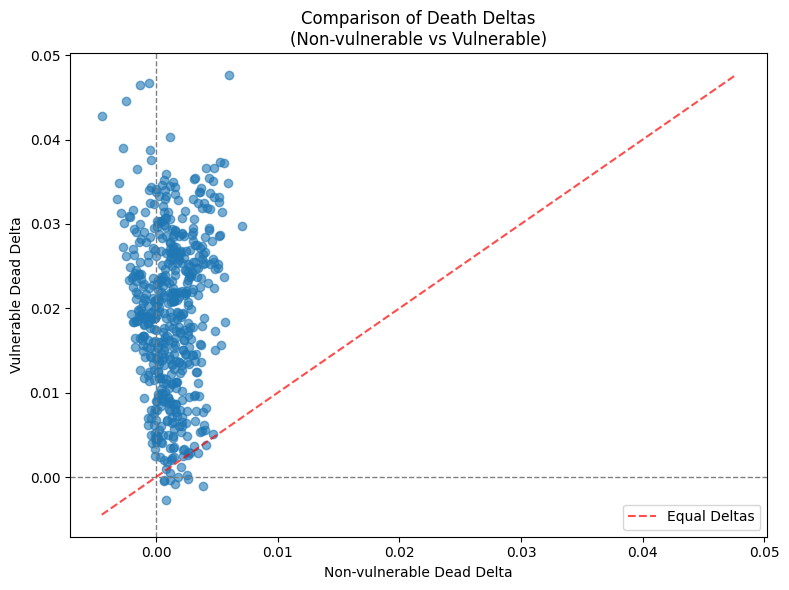

Plot saved to /content/drive/My Drive/Colab Projects/Vaccine Ethics/Results/delta_prop_deaths_comparison.png


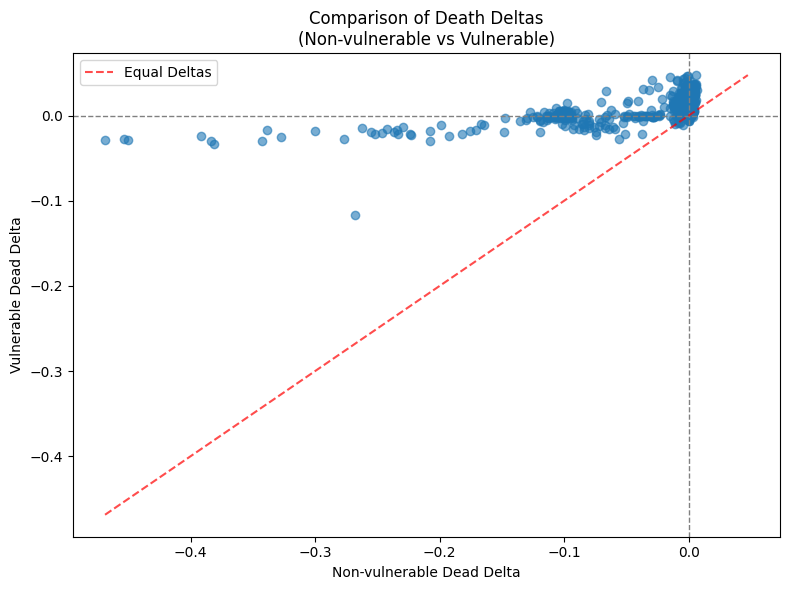

In [9]:
hurts_df = pd.read_csv(dump_path + 'vax_hurts_region_seeding.csv')
df_results = pd.read_csv(dump_path + 'bo_results_fixed_params_seeding.csv')
x = hurts_df['death_prob']
y = hurts_df['vax_effect']
z = hurts_df['viral_age_effect']
print("Viral age effect stats:")
print(hurts_df['viral_age_effect'].describe())
print("Min value in viral_age_effect:", hurts_df['viral_age_effect'].min())
plot_3d_vax_hurts(hurts_df,title='Region where vaccination increased deaths proportion')
plot_3d_delta_auc(df_results,title='Region where vaccination increased infection AUC')
plot_3d_delta_auc(hurts_df,title='Region where vaccination increased both deaths proportion and infection AUC')
plot_dead_delta_comparison(hurts_df)
plot_dead_delta_comparison(df_results)

# Disconnect from Runtime

In [ ]:
from datetime import datetime
import pytz
from IPython.display import Javascript

# Get current time in New York
nyc_time = datetime.now(pytz.timezone('America/New_York'))
formatted_time = nyc_time.strftime('%Y-%m-%d %H:%M:%S %Z')

# Print and log
print(f"✅ Disconnected from runtime at: {formatted_time}")

# Disconnect Colab runtime
display(Javascript('google.colab.kernel.disconnect()'))

✅ Disconnected from runtime at: 2025-08-28 01:20:17 EDT


<IPython.core.display.Javascript object>